# 03 — Sentiment Classification Using TF-IDF N-Gram and Machine Learning

This notebook trains and evaluates binary sentiment classifiers for Kingshot reviews. Review text is represented using TF-IDF N-Gram features, and several machine learning models are compared.

Input file:

```text
data/processed/kingshot_reviews_processed.csv
```

Main outputs:

```text
data/final/kingshot_reviews_classified.csv
data/final/kingshot_reviews_classified.xlsx
outputs/tables/tfidf_classification_report.xlsx
outputs/tables/tfidf_feature_importance.xlsx
outputs/figures/confusion_matrix_all.png
outputs/figures/top_tfidf_features.png
```

The predicted sentiment produced by this notebook is used by the topic modeling stage in notebook `04`.

## 1. Import Libraries and Set Project Paths

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_recall_fscore_support
)
from sklearn.pipeline import Pipeline

APP_NAME = "kingshot"
RANDOM_STATE = 42
TEST_SIZE = 0.2

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() in ["notebook", "notebooks"]:
    BASE_DIR = CURRENT_DIR.parent
else:
    BASE_DIR = CURRENT_DIR

PROCESSED_DIR = BASE_DIR / "data" / "processed"
FINAL_DIR     = BASE_DIR / "data" / "final"
TABLE_DIR     = BASE_DIR / "outputs" / "tables"
FIGURE_DIR    = BASE_DIR / "outputs" / "figures"

for folder in [FINAL_DIR, TABLE_DIR, FIGURE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_colwidth", 250)
pd.set_option("display.max_columns", 100)

print("CURRENT_DIR  :", CURRENT_DIR)
print("BASE_DIR     :", BASE_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("FINAL_DIR    :", FINAL_DIR)
print("TABLE_DIR    :", TABLE_DIR)
print("FIGURE_DIR   :", FIGURE_DIR)


CURRENT_DIR  : d:\Github\kingshot-review-sentiment-analysis\notebook
BASE_DIR     : d:\Github\kingshot-review-sentiment-analysis
PROCESSED_DIR: d:\Github\kingshot-review-sentiment-analysis\data\processed
FINAL_DIR    : d:\Github\kingshot-review-sentiment-analysis\data\final
TABLE_DIR    : d:\Github\kingshot-review-sentiment-analysis\outputs\tables
FIGURE_DIR   : d:\Github\kingshot-review-sentiment-analysis\outputs\figures


## 2. Load Processed Dataset

In [3]:
processed_file = PROCESSED_DIR / f"{APP_NAME}_reviews_processed.csv"

if not processed_file.exists():
    raise FileNotFoundError(
        f"File tidak ditemukan: {processed_file}\n"
        "Jalankan notebook 02 terlebih dahulu."
    )

df = pd.read_csv(processed_file)
df = df.dropna(subset=["clean_text", "sentiment"]).copy()
df = df[df["sentiment"].isin(["negative", "positive"])].copy()
df = df.reset_index(drop=True)

print("Ukuran data:", df.shape)
display(df[["review_text", "clean_text", "rating", "sentiment"]].head())
display(df["sentiment"].value_counts())


Ukuran data: (9640, 17)


,review_text,clean_text,rating,sentiment
0,once again the game is nothing like the ads!! so dumb,once again the game is nothing like the ads so dumb,1,negative
1,"if you are familiar with rise of kingdoms or the mobile age of empires game it's similar to that, very pay 2 win, if you are free to play, you will have no shot and will essentially be fodder. obviously it's not even remotely close to the ads, do...",if you are familiar with rise of kingdoms or the mobile age of empires game it s similar to that very pay 2 win if you are free to play you will have no shot and will essentially be fodder obviously it s not even remotely close to the ads do not ...,1,negative
2,This game has the most intrusive ads that force you to this page to download it,this game has the most intrusive ads that force you to this page to download it,1,negative
3,this game is NOTHING like the ads. this company and the thirsty influencers need to be held accountable. this is basically a multi player castle and unit game that will require money to be competitive. prepare to be disappointed.,this game is nothing like the ads this company and the thirsty influencers need to be held accountable this is basically a multi player castle and unit game that will require money to be competitive prepare to be disappointed,1,negative
4,"games actually not bad, has a whole story line. thought it was some dumb ad that kept popping up. it's not though pretty addictive game.",games actually not bad has a whole story line thought it was some dumb ad that kept popping up it s not though pretty addictive game,5,positive


sentiment
negative    6243
positive    3397
Name: count, dtype: int64

## 3. Split Dataset into Training and Testing Sets

In [4]:
X = df["clean_text"].astype(str)
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print("\nDistribusi train:")
print(y_train.value_counts())
print("\nDistribusi test:")
print(y_test.value_counts())


Train: 7712 | Test: 1928

Distribusi train:
sentiment
negative    4994
positive    2718
Name: count, dtype: int64

Distribusi test:
sentiment
negative    1249
positive     679
Name: count, dtype: int64


## 4. Configure TF-IDF N-Gram Features

The review text is transformed into TF-IDF features using unigram and bigram representations. Sublinear term frequency is used to reduce the effect of extremely frequent terms.

In [5]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    stop_words="english",
    min_df=2,
    max_df=0.95,
    max_features=15000,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("Vocabulary size  :", len(tfidf.vocabulary_))
print("Train matrix     :", X_train_tfidf.shape)
print("Test  matrix     :", X_test_tfidf.shape)


Vocabulary size  : 10396
Train matrix     : (7712, 10396)
Test  matrix     : (1928, 10396)


## 5. Train and Evaluate Sentiment Classifiers

Three supervised machine learning models are evaluated:

```text
Naive Bayes
Linear SVM
Logistic Regression
```

The models are compared using accuracy, precision, recall, and weighted F1-score.

In [6]:
models = {
    "Naive Bayes"         : MultinomialNB(),
    "Linear SVM"          : LinearSVC(random_state=RANDOM_STATE, max_iter=2000),
    "Logistic Regression" : LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
}

results = []

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    acc = accuracy_score(y_test, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted")

    results.append({
        "Model"    : name,
        "Accuracy" : round(acc, 4),
        "Precision": round(p, 4),
        "Recall"   : round(r, 4),
        "F1-Score" : round(f1, 4),
    })

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))

results_df = pd.DataFrame(results)
display(results_df)

report_file = TABLE_DIR / "tfidf_classification_report.xlsx"
results_df.to_excel(report_file, index=False)
print(f"\nReport disimpan ke: {report_file}")



Naive Bayes
              precision    recall  f1-score   support

    negative       0.87      0.98      0.92      1249
    positive       0.94      0.73      0.82       679

    accuracy                           0.89      1928
   macro avg       0.91      0.85      0.87      1928
weighted avg       0.89      0.89      0.89      1928


Linear SVM
              precision    recall  f1-score   support

    negative       0.90      0.94      0.92      1249
    positive       0.88      0.81      0.84       679

    accuracy                           0.89      1928
   macro avg       0.89      0.87      0.88      1928
weighted avg       0.89      0.89      0.89      1928


Logistic Regression
              precision    recall  f1-score   support

    negative       0.88      0.96      0.92      1249
    positive       0.92      0.76      0.83       679

    accuracy                           0.89      1928
   macro avg       0.90      0.86      0.88      1928
weighted avg       0.90     

,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.8890,0.8947,0.8890,0.8852
1,Linear SVM,0.8942,0.8936,0.8942,0.8931
2,Logistic Regression,0.8932,0.8956,0.8932,0.8905



Report disimpan ke: d:\Github\kingshot-review-sentiment-analysis\outputs\tables\tfidf_classification_report.xlsx


## 6. Cross-Validation Evaluation

In [7]:
print("Cross-Validation Score (5-fold)")

cv_rows = []

for name, model in models.items():
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2),
            stop_words="english",
            min_df=2,
            max_df=0.95,
            max_features=15000,
            sublinear_tf=True
        )),
        ("clf", model)
    ])

    scores = cross_val_score(pipe, X, y, cv=5, scoring="f1_weighted")

    cv_rows.append({
        "Model": name,
        "CV F1 Mean": round(scores.mean(), 4),
        "CV F1 Std": round(scores.std(), 4)
    })

cv_results_df = pd.DataFrame(cv_rows).sort_values("CV F1 Mean", ascending=False).reset_index(drop=True)
display(cv_results_df)

cv_file = TABLE_DIR / "tfidf_cross_validation_results.xlsx"
cv_results_df.to_excel(cv_file, index=False)
print(f"Cross-validation results disimpan ke: {cv_file}")

Cross-Validation Score (5-fold)


,Model,CV F1 Mean,CV F1 Std
0,Linear SVM,0.9067,0.0053
1,Logistic Regression,0.9045,0.0063
2,Naive Bayes,0.8922,0.0072


Cross-validation results disimpan ke: d:\Github\kingshot-review-sentiment-analysis\outputs\tables\tfidf_cross_validation_results.xlsx


## 7. Confusion Matrix Visualization

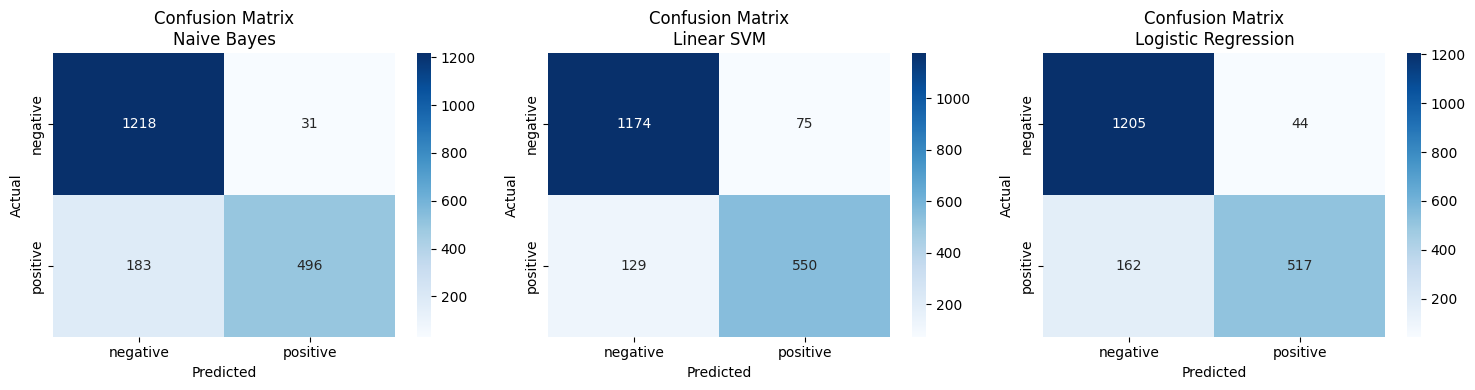

Figure disimpan ke: d:\Github\kingshot-review-sentiment-analysis\outputs\figures\confusion_matrix_all.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_tfidf)
    cm = confusion_matrix(y_test, y_pred, labels=["negative", "positive"])

    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["negative", "positive"],
        yticklabels=["negative", "positive"],
        ax=ax
    )
    ax.set_title(f"Confusion Matrix\n{name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
fig_file = FIGURE_DIR / "confusion_matrix_all.png"
plt.savefig(fig_file, dpi=150)
plt.show()
print(f"Figure disimpan ke: {fig_file}")


## 8. Top TF-IDF Features per Sentiment Class

The Logistic Regression coefficients are used to inspect the most influential TF-IDF features for positive and negative sentiment classes. This step is used for interpretation, not for final model selection.

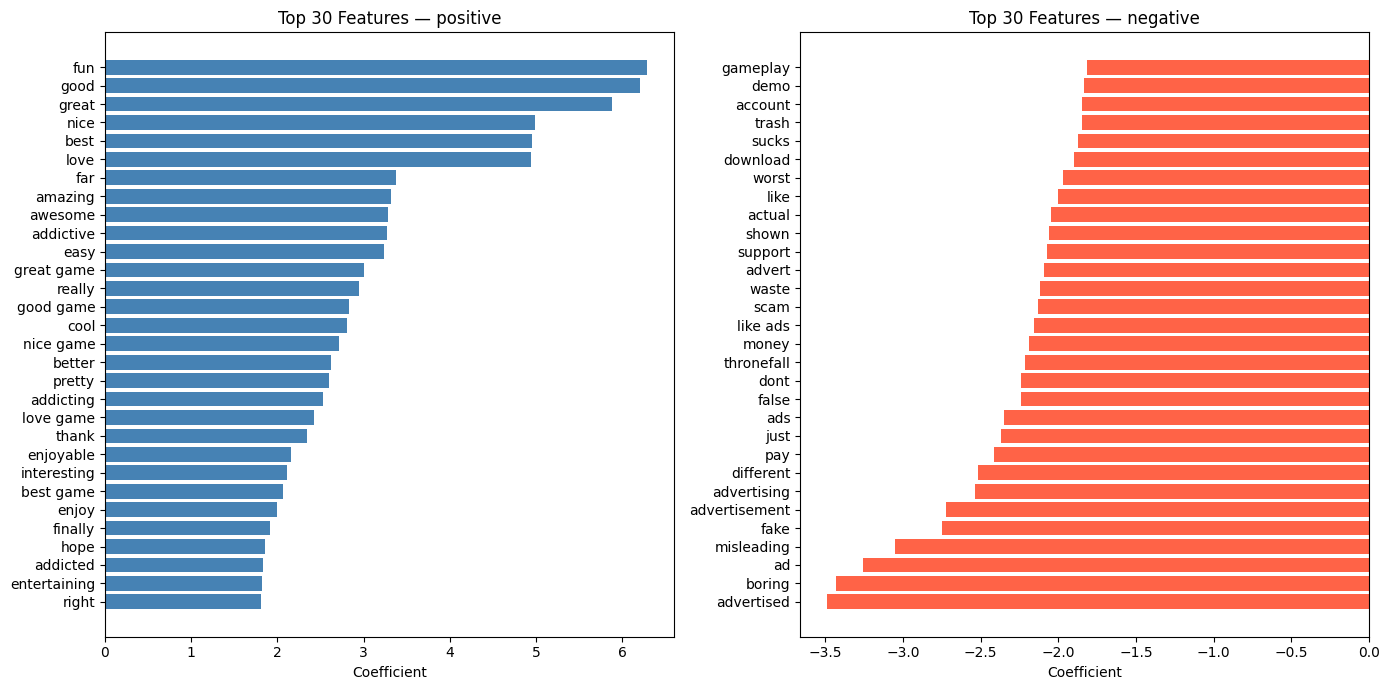

Feature importance disimpan ke: d:\Github\kingshot-review-sentiment-analysis\outputs\tables\tfidf_feature_importance.xlsx


In [9]:
lr_model = models["Logistic Regression"]
feature_names = np.array(tfidf.get_feature_names_out())

# Binary LR: coef_ shape (1, n_features)
# positif = koefisien tinggi, negatif = koefisien rendah
coefs = lr_model.coef_[0]

top_pos_idx = coefs.argsort()[-30:][::-1]    # paling positif
top_neg_idx = coefs.argsort()[:30]            # paling negatif

feature_rows = []

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Kelas positive
axes[0].barh(feature_names[top_pos_idx][::-1], coefs[top_pos_idx][::-1], color="steelblue")
axes[0].set_title("Top 30 Features — positive")
axes[0].set_xlabel("Coefficient")
for feat, coef in zip(feature_names[top_pos_idx], coefs[top_pos_idx]):
    feature_rows.append({"sentiment": "positive", "feature": feat, "coefficient": round(coef, 4)})

# Kelas negative
axes[1].barh(feature_names[top_neg_idx], coefs[top_neg_idx], color="tomato")
axes[1].set_title("Top 30 Features — negative")
axes[1].set_xlabel("Coefficient")
for feat, coef in zip(feature_names[top_neg_idx], coefs[top_neg_idx]):
    feature_rows.append({"sentiment": "negative", "feature": feat, "coefficient": round(coef, 4)})

plt.tight_layout()
fig_file = FIGURE_DIR / "top_tfidf_features.png"
plt.savefig(fig_file, dpi=150)
plt.show()

feature_df = pd.DataFrame(feature_rows)
feat_file = TABLE_DIR / "tfidf_feature_importance.xlsx"
feature_df.to_excel(feat_file, index=False)
print(f"Feature importance disimpan ke: {feat_file}")

## 9. Save Classified Dataset

In [10]:
# Gunakan model terbaik berdasarkan F1-Score
best_model_name = results_df.sort_values("F1-Score", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]
print(f"Model terbaik: {best_model_name}")

X_all_tfidf = tfidf.transform(df["clean_text"].astype(str))
df["predicted_sentiment"] = best_model.predict(X_all_tfidf)
df["sentiment_match"] = df["sentiment"] == df["predicted_sentiment"]

display(df[["review_text", "clean_text", "rating", "sentiment", "predicted_sentiment", "sentiment_match"]].head(20))

csv_file  = FINAL_DIR / f"{APP_NAME}_reviews_classified.csv"
xlsx_file = FINAL_DIR / f"{APP_NAME}_reviews_classified.xlsx"

df.to_csv(csv_file, index=False)
df.to_excel(xlsx_file, index=False)

print(f"\nData final disimpan ke: {csv_file}")
print(f"Data final disimpan ke: {xlsx_file}")
print(f"\nTotal review: {len(df)}")
print(f"Prediksi cocok dengan label asli: {df['sentiment_match'].sum()} ({df['sentiment_match'].mean():.1%})")


Model terbaik: Linear SVM


,review_text,clean_text,rating,sentiment,predicted_sentiment,sentiment_match
0,once again the game is nothing like the ads!! so dumb,once again the game is nothing like the ads so dumb,1,negative,negative,True
1,"if you are familiar with rise of kingdoms or the mobile age of empires game it's similar to that, very pay 2 win, if you are free to play, you will have no shot and will essentially be fodder. obviously it's not even remotely close to the ads, do...",if you are familiar with rise of kingdoms or the mobile age of empires game it s similar to that very pay 2 win if you are free to play you will have no shot and will essentially be fodder obviously it s not even remotely close to the ads do not ...,1,negative,negative,True
2,This game has the most intrusive ads that force you to this page to download it,this game has the most intrusive ads that force you to this page to download it,1,negative,negative,True
3,this game is NOTHING like the ads. this company and the thirsty influencers need to be held accountable. this is basically a multi player castle and unit game that will require money to be competitive. prepare to be disappointed.,this game is nothing like the ads this company and the thirsty influencers need to be held accountable this is basically a multi player castle and unit game that will require money to be competitive prepare to be disappointed,1,negative,negative,True
4,"games actually not bad, has a whole story line. thought it was some dumb ad that kept popping up. it's not though pretty addictive game.",games actually not bad has a whole story line thought it was some dumb ad that kept popping up it s not though pretty addictive game,5,positive,positive,True
5,amazing game and amazing community would defo recommend 👌,amazing game and amazing community would defo recommend,5,positive,positive,True
6,love this game 🎮,love this game,5,positive,positive,True
7,different from the ads,different from the ads,1,negative,negative,True
8,not the game advertised,not the game advertised,1,negative,negative,True
9,This is not a good game. you aboutly don't download it,this is not a good game you aboutly dont download it,1,negative,negative,True



Data final disimpan ke: d:\Github\kingshot-review-sentiment-analysis\data\final\kingshot_reviews_classified.csv
Data final disimpan ke: d:\Github\kingshot-review-sentiment-analysis\data\final\kingshot_reviews_classified.xlsx

Total review: 9640
Prediksi cocok dengan label asli: 9353 (97.0%)


## 10. Note

Sentiment labels are derived from user ratings rather than manual annotation. This approach enables scalable sentiment classification, but the labels reflect rating-based sentiment assumptions. The trained classifier is used to predict sentiment labels for the cleaned review dataset, which is then used as input for complaint topic modeling in the next notebook.